<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY_12_Ada_Boost_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# making model from scratch

In [1]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [2]:
df=pd.DataFrame()

In [3]:
df['x1']=[1,2,3,4,5,6,6,7,9,9]
df['x2']=[5,3,6,8,1,9,5,8,9,2]
df['label']=[1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

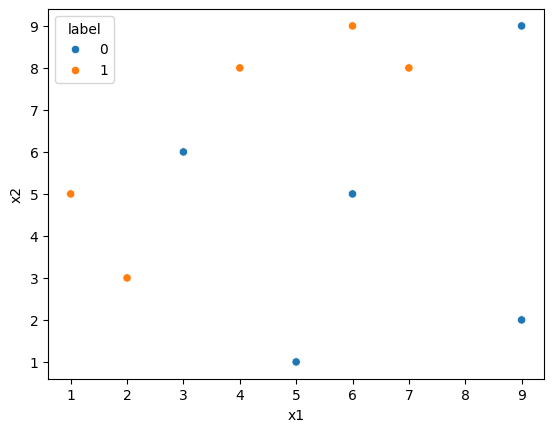

In [5]:
import seaborn as sns
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])

In [6]:
df['weight']=1/df.shape[0]

In [7]:
df

,x1,x2,label,weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=1)

In [9]:
x=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [10]:
dt.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

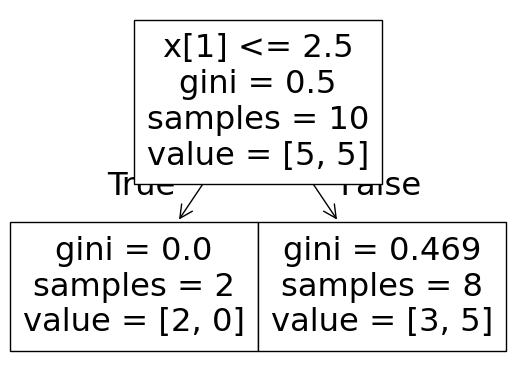

In [11]:
from sklearn.tree import plot_tree
plot_tree(dt)

<Axes: >

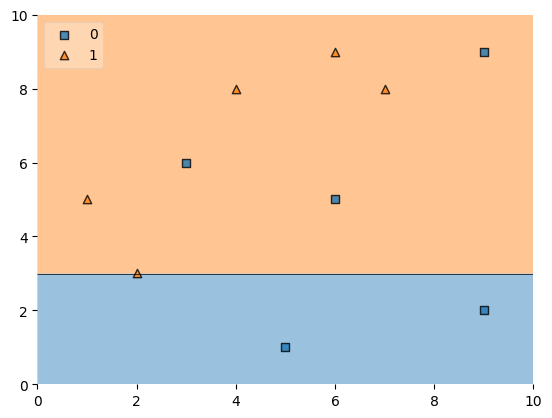

In [12]:
plot_decision_regions(x,y,clf=dt,legend=2)

In [13]:
df['y_pred']=dt.predict(x)

In [14]:
df

,x1,x2,label,weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [15]:
def calculate_model_weight(error):
  return 0.5*np.log(1-error)/(error)

In [16]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(-0.5944582398978875)

In [17]:
def update_row_weight(row, alpha= np.round(alpha1,3)):
  if row['label']==row['y_pred']:
    return row['weight']*np.exp(-alpha)
  else:
    return row['weight']*np.exp(alpha)

In [18]:
df['updated_weight'] = df.apply(update_row_weight, axis=1)

In [19]:
df

,x1,x2,label,weight,y_pred,updated_weight
0,1,5,1,0.1,1,0.181122
1,2,3,1,0.1,1,0.181122
2,3,6,0,0.1,1,0.055211
3,4,8,1,0.1,1,0.181122
4,5,1,0,0.1,0,0.181122
5,6,9,1,0.1,1,0.181122
6,6,5,0,0.1,1,0.055211
7,7,8,1,0.1,1,0.181122
8,9,9,0,0.1,1,0.055211
9,9,2,0,0.1,0,0.181122


In [20]:
df['updated_weight'].sum()

np.float64(1.4334874954520802)

In [21]:
# normalization
df['normalized_weight']=df['updated_weight']/df['updated_weight'].sum()

In [22]:
df['normalized_weight'].sum()

np.float64(1.0)

making range

In [23]:
df['cumsum_upper']=np.cumsum(df['normalized_weight'])
df['cumsum_lower']= np.cumsum(df['normalized_weight'])-df['normalized_weight']

In [24]:
df

,x1,x2,label,weight,y_pred,updated_weight,normalized_weight,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.181122,0.126351,0.126351,0.000000
1,2,3,1,0.1,1,0.181122,0.126351,0.252701,0.126351
2,3,6,0,0.1,1,0.055211,0.038515,0.291216,0.252701
3,4,8,1,0.1,1,0.181122,0.126351,0.417567,0.291216
4,5,1,0,0.1,0,0.181122,0.126351,0.543918,0.417567
5,6,9,1,0.1,1,0.181122,0.126351,0.670268,0.543918
6,6,5,0,0.1,1,0.055211,0.038515,0.708784,0.670268
7,7,8,1,0.1,1,0.181122,0.126351,0.835134,0.708784
8,9,9,0,0.1,1,0.055211,0.038515,0.873649,0.835134
9,9,2,0,0.1,0,0.181122,0.126351,1.000000,0.873649


In [25]:
def create_new_dataset(df):
  indices=[]
  for i in range(df.shape[0]):
    a=np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper']> a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [26]:
index_values = create_new_dataset(df)
index_values

[0, 7, 1, 2, 2, 0, 9, 1, 9, 3]

In [27]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [28]:
second_df

,x1,x2,label,weight
0,1,5,1,0.1
7,7,8,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1
0,1,5,1,0.1
9,9,2,0,0.1
1,2,3,1,0.1
9,9,2,0,0.1
3,4,8,1,0.1


In [29]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [30]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [31]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.625, 0.5, '  False')]

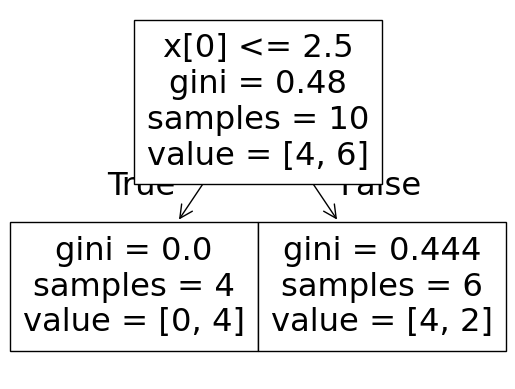

In [32]:
plot_tree(dt2)

<Axes: >

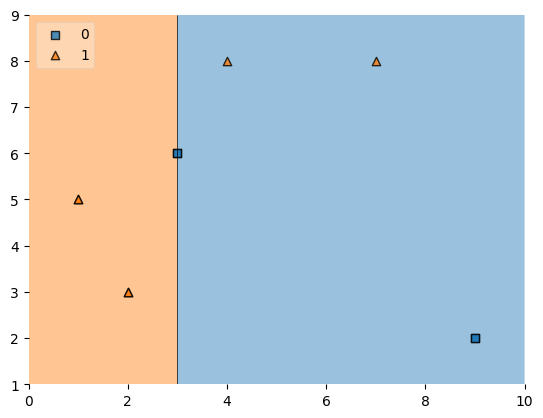

In [33]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [34]:
second_df['y_pred'] = dt2.predict(X)

In [35]:
second_df

,x1,x2,label,weight,y_pred
0,1,5,1,0.1,1
7,7,8,1,0.1,0
1,2,3,1,0.1,1
2,3,6,0,0.1,0
2,3,6,0,0.1,0
0,1,5,1,0.1,1
9,9,2,0,0.1,0
1,2,3,1,0.1,1
9,9,2,0,0.1,0
3,4,8,1,0.1,0


In [36]:
alpha2 = calculate_model_weight(0.1)

In [37]:

alpha2

np.float64(-0.5268025782891314)

In [38]:
# Step 4 - Update weights
def update_row_weight(row, alpha= np.round(alpha2,3)):
  if row['label']==row['y_pred']:
    return row['weight']*np.exp(-alpha)
  else:
    return row['weight']*np.exp(alpha)

In [39]:
second_df['updated_weights'] = second_df.apply(update_row_weight,axis=1)

In [40]:
second_df

,x1,x2,label,weight,y_pred,updated_weights
0,1,5,1,0.1,1,0.169384
7,7,8,1,0.1,0,0.059037
1,2,3,1,0.1,1,0.169384
2,3,6,0,0.1,0,0.169384
2,3,6,0,0.1,0,0.169384
0,1,5,1,0.1,1,0.169384
9,9,2,0,0.1,0,0.169384
1,2,3,1,0.1,1,0.169384
9,9,2,0,0.1,0,0.169384
3,4,8,1,0.1,0,0.059037


In [41]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [42]:
second_df

,x1,x2,label,weight,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.169384,0.114981
7,7,8,1,0.1,0,0.059037,0.040076
1,2,3,1,0.1,1,0.169384,0.114981
2,3,6,0,0.1,0,0.169384,0.114981
2,3,6,0,0.1,0,0.169384,0.114981
0,1,5,1,0.1,1,0.169384,0.114981
9,9,2,0,0.1,0,0.169384,0.114981
1,2,3,1,0.1,1,0.169384,0.114981
9,9,2,0,0.1,0,0.169384,0.114981
3,4,8,1,0.1,0,0.059037,0.040076


In [43]:
second_df['nomalized_weights'].sum()

np.float64(1.0000000000000002)

In [44]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [45]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [46]:
second_df[['x1','x2','label','weight','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,x1,x2,label,weight,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.114981,0.000000,0.114981
7,7,8,1,0.1,0,0.040076,0.114981,0.155057
1,2,3,1,0.1,1,0.114981,0.155057,0.270038
2,3,6,0,0.1,0,0.114981,0.270038,0.385019
2,3,6,0,0.1,0,0.114981,0.385019,0.500000
0,1,5,1,0.1,1,0.114981,0.500000,0.614981
9,9,2,0,0.1,0,0.114981,0.614981,0.729962
1,2,3,1,0.1,1,0.114981,0.729962,0.844943
9,9,2,0,0.1,0,0.114981,0.844943,0.959924
3,4,8,1,0.1,0,0.040076,0.959924,1.000000


In [47]:
index_values = create_new_dataset(second_df)

In [48]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [49]:
third_df

,x1,x2,label,weight
1,2,3,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
0,1,5,1,0.1
1,2,3,1,0.1
3,4,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
3,4,8,1,0.1


In [50]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

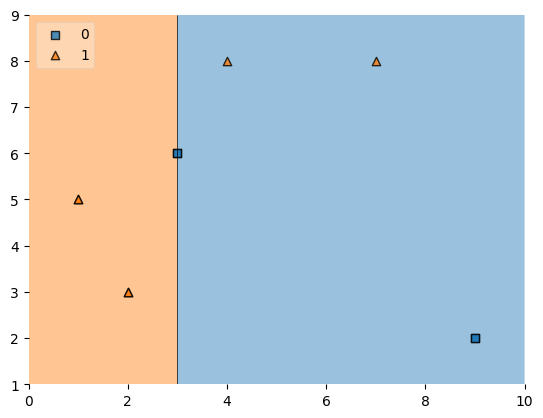

In [51]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [52]:
third_df['y_pred'] = dt3.predict(X)

In [53]:
third_df

,x1,x2,label,weight,y_pred
1,2,3,1,0.1,1
1,2,3,1,0.1,0
2,3,6,0,0.1,1
0,1,5,1,0.1,0
1,2,3,1,0.1,0
3,4,8,1,0.1,1
7,7,8,1,0.1,0
7,7,8,1,0.1,1
7,7,8,1,0.1,0
3,4,8,1,0.1,0


In [54]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.8599805745185257)

In [55]:
print(alpha1,alpha2,alpha3)

-0.5944582398978875 -0.5268025782891314 -0.8599805745185257


# Prediction

In [56]:
query = np.array([1,5]).reshape(1,2)
dt.predict(query)

array([1])

In [57]:
dt2.predict(query)

array([1])

In [58]:
dt3.predict(query)

array([1])

In [59]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(-1.9812413927055448)

In [60]:
np.sign(1.09)

np.float64(1.0)

In [61]:
query = np.array([9,9]).reshape(1,2)
dt.predict(query)

array([1])

In [62]:
dt2.predict(query)

array([0])

In [63]:
dt3.predict(query)

array([0])

In [64]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(0.7923249129097696)

In [65]:
np.sign(-0.25)

np.float64(-1.0)